<a href="https://colab.research.google.com/github/Nithin025au/IDSS-Lab/blob/main/2_Decision_tree_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [102]:
import pandas as pd
df=pd.read_csv("loan_approval.csv")
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [103]:
df=df.drop('name',axis=1)
display(df.head())

,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,East Jill,113810,389,39698,27,50.0,False
1,New Jamesside,44592,729,15446,28,55.0,False
2,Lake Roberto,33278,584,11189,13,45.0,False
3,West Melanieview,127196,344,48823,29,50.0,False
4,Mariastad,66048,496,47174,4,25.0,False


In [104]:
# Drop the 'points' column to mitigate data leakage
df = df.drop('points', axis=1)
print("'points' column dropped due to data leakage.")
display(df.head())

'points' column dropped due to data leakage.


,city,income,credit_score,loan_amount,years_employed,loan_approved
0,East Jill,113810,389,39698,27,False
1,New Jamesside,44592,729,15446,28,False
2,Lake Roberto,33278,584,11189,13,False
3,West Melanieview,127196,344,48823,29,False
4,Mariastad,66048,496,47174,4,False


In [105]:
# Identify categorical and numerical features
categorical_features = ['city']
numerical_features = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']
df.head()

,city,income,credit_score,loan_amount,years_employed,loan_approved
0,East Jill,113810,389,39698,27,False
1,New Jamesside,44592,729,15446,28,False
2,Lake Roberto,33278,584,11189,13,False
3,West Melanieview,127196,344,48823,29,False
4,Mariastad,66048,496,47174,4,False


In [106]:
# Perform one-hot encoding for categorical features
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Display the first few rows of the preprocessed DataFrame
display(df.head(10))

,income,credit_score,loan_amount,years_employed,loan_approved,city_Adamburgh,city_Adamland,city_Adammouth,city_Adamsfort,city_Adamsfurt,...,city_Wilsonton,city_Wilsonview,city_Wongburgh,city_Woodsburgh,city_Wrightchester,city_Yatesbury,city_Youngbury,city_Yumouth,city_Zacharyton,city_Zamoramouth
0,113810,389,39698,27,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,44592,729,15446,28,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,33278,584,11189,13,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,127196,344,48823,29,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,66048,496,47174,4,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,62098,689,19217,29,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,59256,373,40920,40,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,48289,524,45866,20,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,126530,367,14826,36,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9,43434,446,18359,8,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [110]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 1400 samples
Test set size: 600 samples


In [108]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree Classifier instance with a limited max_depth to prevent overfitting
decision_tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)

# Train the model on the training data
decision_tree_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully with max_depth=5!")

Decision Tree Classifier trained successfully with max_depth=5!


### Model Evaluation

After training, we will evaluate the performance of our Decision Tree model on the test set. We'll use common classification metrics such as accuracy, precision, recall, and F1-score, along with a confusion matrix, to understand how well the model predicts loan approvals.

Accuracy: 0.9450

Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.93      0.95       333
        True       0.91      0.97      0.94       267

    accuracy                           0.94       600
   macro avg       0.94      0.95      0.94       600
weighted avg       0.95      0.94      0.95       600



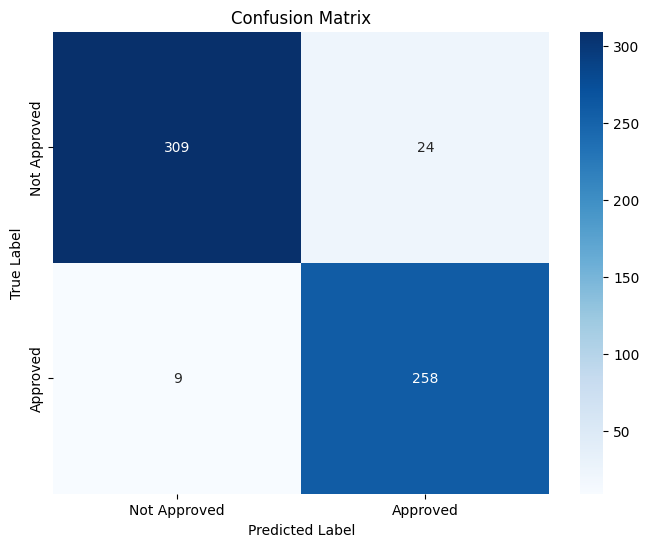

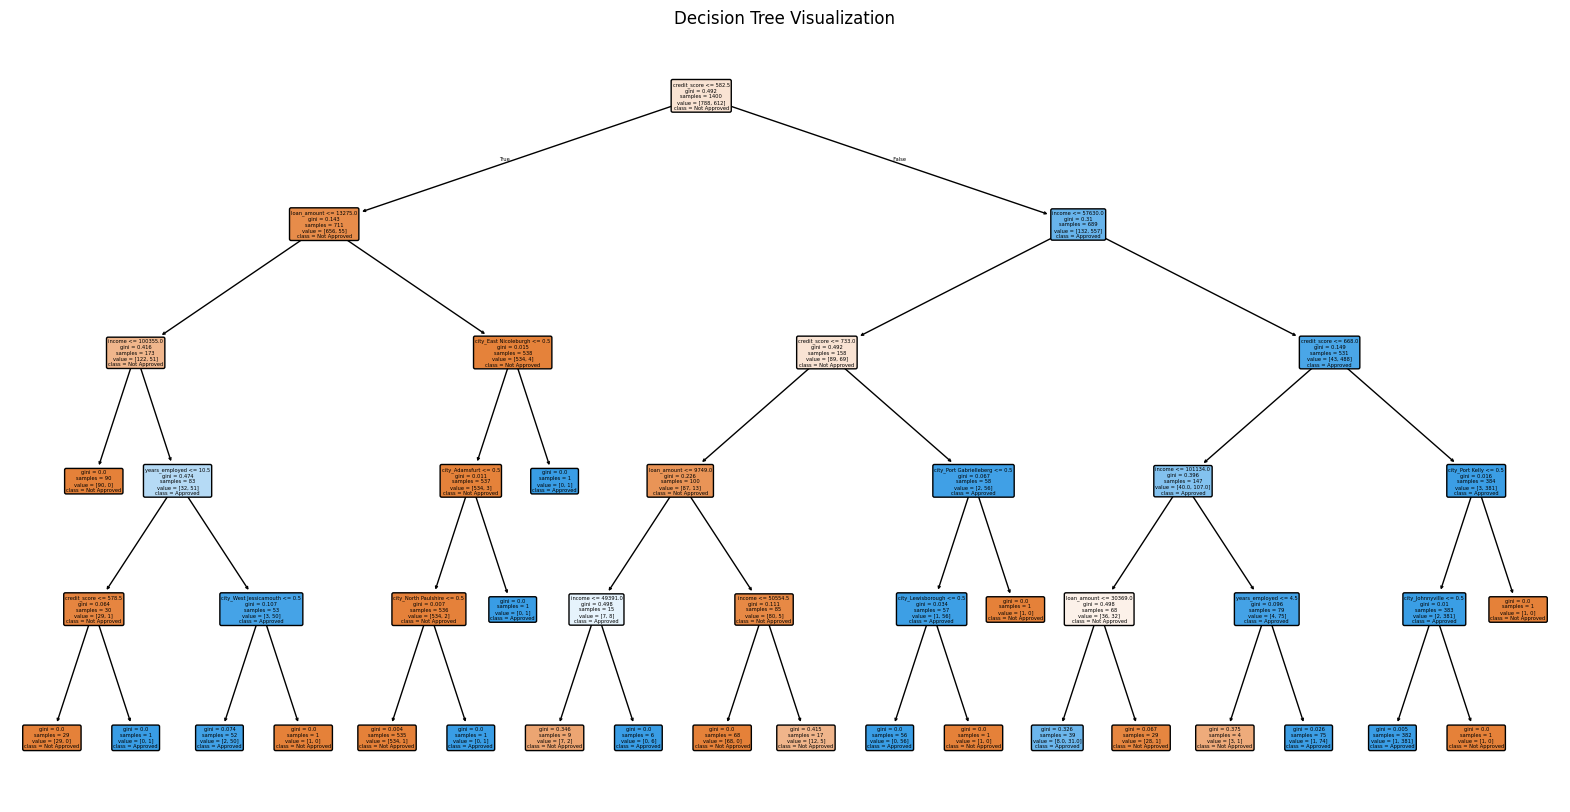


Text-based Decision Rules:
|--- credit_score <= 582.50
|   |--- loan_amount <= 13275.00
|   |   |--- income <= 100355.00
|   |   |   |--- class: Not Approved
|   |   |--- income >  100355.00
|   |   |   |--- years_employed <= 10.50
|   |   |   |   |--- credit_score <= 578.50
|   |   |   |   |   |--- class: Not Approved
|   |   |   |   |--- credit_score >  578.50
|   |   |   |   |   |--- class: Approved
|   |   |   |--- years_employed >  10.50
|   |   |   |   |--- city_West Jessicamouth <= 0.50
|   |   |   |   |   |--- class: Approved
|   |   |   |   |--- city_West Jessicamouth >  0.50
|   |   |   |   |   |--- class: Not Approved
|   |--- loan_amount >  13275.00
|   |   |--- city_East Nicoleburgh <= 0.50
|   |   |   |--- city_Adamsfurt <= 0.50
|   |   |   |   |--- city_North Paulshire <= 0.50
|   |   |   |   |   |--- class: Not Approved
|   |   |   |   |--- city_North Paulshire >  0.50
|   |   |   |   |   |--- class: Approved
|   |   |   |--- city_Adamsfurt >  0.50
|   |   |   |   |---

In [109]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

# Make predictions on the test set
y_pred = decision_tree_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Interpret the generated decision rules by visualizing the tree
plt.figure(figsize=(20,10))
tree.plot_tree(decision_tree_model, feature_names=X.columns, class_names=['Not Approved', 'Approved'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

# You can also print text-based rules for easier interpretation
print("\nText-based Decision Rules:")
text_representation = tree.export_text(decision_tree_model, feature_names=list(X.columns), class_names=['Not Approved', 'Approved'])
print(text_representation)